In [12]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs
from Bio.Seq import Seq

Создадим генератор случайных посл-тей:

In [13]:
def rand_seq(length):
    probs = [0.295, 0.295, 0.205, 0.205] #A/T : 0.295, G/C : 0.205
    return ''.join(np.random.choice(list("ATGC"), size=length, p=probs))

Введем данные из Задания 1:

In [18]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
         "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
         "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
         "CAGGTTGGC"]

instances = [Seq(site) for site in sites]
m = motifs.create(instances)

background = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
ppm = m.counts.normalize(pseudocounts=1)
pwm = ppm.log_odds(background)
print(pwm)

        0      1      2      3      4      5      6      7      8
A:  -1.05   1.12  -1.05  -2.05  -2.05  -0.46   0.95  -0.46  -1.05
C:   1.29   0.06  -0.52  -1.52  -1.52   1.29  -1.52  -1.52   1.65
G:  -0.52  -1.52   1.65   1.94  -1.52  -1.52   0.48   1.65  -1.52
T:  -0.46  -2.05  -2.05  -2.05   1.41  -0.46  -2.05  -2.05  -1.05



In [20]:
n_seqs = 100_000
seq_len = 9
scores = []

for i in range(n_seqs):
    seq = rand_seq(seq_len)
    score = 0
    for pos, base in enumerate(seq):
        score += pwm[base][pos]
    scores.append(score)

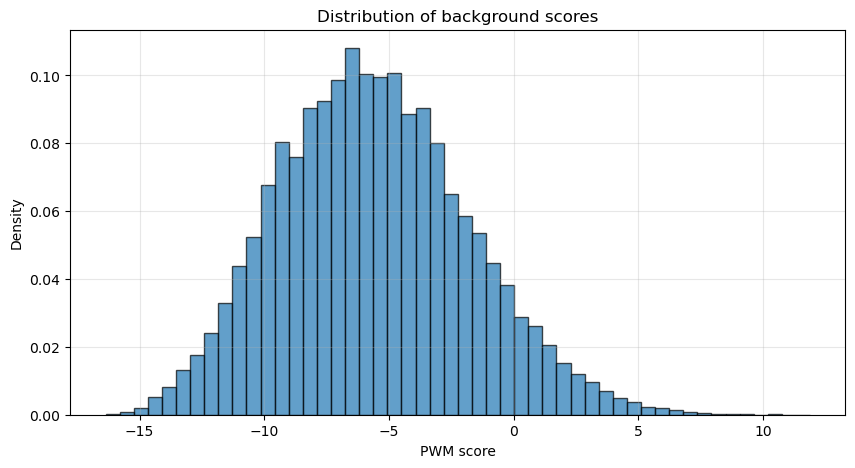

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('PWM score')
plt.ylabel('Density')
plt.title('Distribution of background scores')
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
def get_value(score):
    return np.mean(np.array(scores) >= score)

target_p = 1e-4
sorted_scores = sorted(scores, reverse=True)
threshold = sorted_scores[int(target_p * len(sorted_scores))]

print(f"Target p-value: {target_p}")
print(f"Threshold: {threshold:.4f}")
print(f"Actual p-value: {get_value(threshold):.6f}")

Target p-value: 0.0001
Threshold: 9.3937
Actual p-value: 0.000110
